<a href="https://colab.research.google.com/github/owen-ml/OBrown_DIS9200A_v1_ASLR/blob/main/DataAccusition_WLASL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#WLASL Data Accusition Chapter 3




> 3.1 Download All Videos

> 3.2 Create Classes of Raw Videos

> 3.3 Generated EDA Metadata










The !nvidia-smi command (NVIDIA System Management Interface) is a command-line utility used to monitor and manage NVIDIA GPU devices, commonly run in Jupyter notebooks or terminal environments to display real-time GPU health, performance, utilization, memory usage temperature, and power consumption. It provides a detailed status report for troubleshooting and optimization.


In [1]:
!nvidia-smi


/bin/bash: line 1: nvidia-smi: command not found


** Load Google Colab & File Locations**

---


*  Clone Github Repository
*  Create File Folder in Google Docs





In [2]:
%cd /content/drive/MyDrive  # Mounts Google Drive
!git clone https://github.com/dxli94/WLASL.git # Clones WLASL git Repository



/content/drive/MyDrive
fatal: destination path 'WLASL' already exists and is not an empty directory.


*The data about to be donwnloaded is very large. The set up creates a temporary WLASL file. All the Videos are downloaed to this file. If The runtime is reset or the session disconnects the tempoary WLASL file will be deleted perminatly. To avoid this problem download the file directly to Google drive for perminate storage*

In [3]:
# Change Directory to WLSAL
%cd /content/drive/MyDrive/WLASL/start_kit



/content/drive/MyDrive/WLASL/start_kit


# # 3.1  Download all the Videos

*To collect the files a downloader.py and preprocessor.py in the WLASL/start_kit are designed to automate the acquisition and standardization of the WLASL dataset. The downloader.py downloads the files and the preprocessor.py convers the files to an mp4 format.  The download.py was modified to make 2 attempts to collect the file and move to the next regardless of success. This step helped limit the number of unreadable files during sample collection. In addtion Youtube has a significant amount of toutorial and padded videos that are not useful for training. Those vidoes were skipped.*

In [4]:
# Modifictions can be found in the script for downloader and preprocessing.
!python video_downloader.py
!python preprocess.py


Start downloading videos (YouTube + non-YouTube).
yt-dlp not found. Non-YouTube videos will download; YouTube will be skipped.
To enable YouTube downloads in Colab:
  !pip -q install yt-dlp
or
  !apt-get -y update && apt-get -y install yt-dlp

[1/2] gloss=book video_id=69241 url=http://aslbricks.org/New/ASL-Videos/book.mp4
[DIRECT] exists -> raw_videos_mp4/69241.mp4
[1/2] gloss=book video_id=65225 url=https://aslsignbank.haskins.yale.edu/dictionary/protected_media/glossvideo/ASL/BO/BOOK-418.mp4
[2/2] gloss=book video_id=65225 url=https://aslsignbank.haskins.yale.edu/dictionary/protected_media/glossvideo/ASL/BO/BOOK-418.mp4
[FAIL] gloss=book video_id=65225 reason=Network error: <urlopen error [SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: Hostname mismatch, certificate is not valid for 'aslsignbank.haskins.yale.edu'. (_ssl.c:1010)>
[SKIP-YT] yt-dlp not available. Skipping YouTube video_id=68011 url=https://www.youtube.com/watch?v=0UsjUE-TXns
[SKIP-YT] yt-dlp not available. 

In [1]:
# Occasionally Google Colab needs to be mounted again. This can occur when runtime is rest or if the system times out when not being used for along period of time.
#from google.colab import drive
#drive.mount('/content/drive')


#3.2 Create Classes of Raw Videos (mp4)

* All of the videos are in the WLASL/Start_kit/raw_videos_mp4 directory. They need to be grouped by the associated gloss and placed in a subfolder containing the name of the gloss.*  

**3.2.1  Folder Set up**

*First the folders must be set up: The Following Code is setting up the folder paths and environment for a dataset‑processing script. Nothing is being processed yet — it’s just defining where things live and making sure the output folder exists.*


In [7]:
#-------Import Pyhon Dependencies
import os # Works with os files. shutill
import json # for json files
import shutil #for shutil files
from collections import defaultdict # fro grouping data defalutdict
#-------------------------------------------


# Define  the souce fo teh videos in the directory
VIDEOS_DIR = (
    "/content/drive/MyDrive/WLASL/start_kit/raw_videos_mp4"
)

# WLASL annotation file contains the gloss and the name of the file. This is used to create the classes
'''This is the WLASL dataset annotation file, which maps:
- video IDs → gloss labels
- metadata like signer, frame ranges, etc.'''

JSON_PATH = (
    "/content/drive/MyDrive/WLASL/start_kit/WLASL_v0.3.json"
)

# Destination labeled dataset: Defines the output directory  where the scrip twill save the orgaized., labled dat aset after this process
OUTPUT_DIR = (
    "/content/drive/MyDrive/Consultant/Colab_Notebooks/Obrown_Dissertation_NU_25/ASL_Raw_Data"
)

#This ensures the folder exists so the script can write files into it#
os.makedirs(OUTPUT_DIR, exist_ok=True)


**3.2.2** Map Lables with json**

*This block is taking the WLASL JSON annotation file and turning it into a simple Python dictionary that maps each video_id → gloss label. In other words, it builds a lookup table so the script can figure out what sign each video represents*

In [ ]:
# Loding json File
with open(JSON_PATH, "r") as f:
    content = json.load(f)



videoid_to_gloss = {}  #Creating an empty dictionary

# Use a for loop to Loop through all entries in the JSON
for entry in content:
    gloss = entry["gloss"]
    for inst in entry["instances"]:
        video_id = inst["video_id"]
        videoid_to_gloss[video_id] = gloss

#Printing how many mappings were created

print(f"Loaded {len(videoid_to_gloss)} video_id → gloss mappings")


**3.2.3** Copy mp4 to Correct Gloss**

*actual dataset organization. It goes through every  file in your raw video folder, checks whether that video has a gloss label in the WLASL JSON, and if so, copies it into the correct labeled folder.
Here’s the flow in clear steps:*


In [ ]:
#--- Set up counters to catch missing gloss albles and correctly coped lables to folders
missing = 0
copied = 0
#---------------

#Loop Through all the files in the raw video directory
for fname in os.listdir(VIDEOS_DIR):
    if not fname.endswith(".mp4"): # make sure only vidoes are processed
        continue

    video_id = fname.replace(".mp4", "") # Extract the video ID from the filename
    src_path = os.path.join(VIDEOS_DIR, fname) #Build the full path to the source file

     #Check if this video ID exists in the JSON mapping
     # If the JSON doesn’t contain this video ID: - It increments missing - Skips the file



    if video_id not in videoid_to_gloss:
        missing += 1
        continue


    gloss = videoid_to_gloss[video_id]  #Get the gloss label for this video

    # Create gloss folder
    gloss_dir = os.path.join(OUTPUT_DIR, gloss)
    os.makedirs(gloss_dir, exist_ok=True)

    dst_path = os.path.join(gloss_dir, fname) #Copy the video into the gloss folder

    #- Avoids overwriting if the file already exists
    #- Uses copy2 to preserve metadata (timestamps, etc.)


    if not os.path.exists(dst_path):
        shutil.copy2(src_path, dst_path)
        copied += 1
#Print summary
print(f"Copied {copied} videos")
print(f"Skipped {missing} videos with no gloss mapping")


**3.2.4 Check to see if Changes Were Sucessful**

*just a quick way to peek inside one of your gloss folders and see how many videos ended up there*


In [ ]:
#just check number of items in teh output directory
len(os.listdir(OUTPUT_DIR))


In [ ]:

example_gloss = os.listdir(OUTPUT_DIR)[0]
print(example_gloss)
print(len(os.listdir(os.path.join(OUTPUT_DIR, example_gloss))))


In [ ]:
 #line is counting every video file inside every gloss folder in your labeled dataset

total = sum(
    len(files)
    for _, _, files in os.walk(OUTPUT_DIR)
)
print("Total labeled videos:", total)


# 3.3 Generated EDA Metadata

# 3.3.1 *Video Quality Report*


*   full automated quality‑check of your ASL video dataset.

*   Visual of Status



In [ ]:
#Install Depenencies

import os
from pathlib import Path
import cv2  #open cv
import pandas as pd # pandas for tabular data


# ====== CONFIG  root, where vidoes are now and out put where the metadata will go
ROOT_DIR = Path("/content/drive/MyDrive/Consultant/Colab_Notebooks/Obrown_Dissertation_NU_25/ASL_Raw_Data")
OUTPUT_CSV = ROOT_DIR / "video_quality_report_step1.csv" #name of file to be created

VIDEO_EXTS = {".mp4", ".mov", ".avi", ".mkv", ".webm"}  # this only has mp4 however if you can edit if needed

#define inspection function

def inspect_video(video_path: Path) -> dict:
    """
    Step 1 — Inspect Video Quality Using Python (OpenCV)
    Checks:
      - Video is readable (can open)
      - Video has at least 1 frame
      - Can read first frame (detects early corruption)
      - Width/Height/FPS/Frame count metadata
    """
    video_path_str = str(video_path)

    cap = cv2.VideoCapture(video_path_str) #Can the video be opened?

    # If cannot open, it's unreadable
    if not cap.isOpened():
        return {
            "video": video_path_str,
            "status": "Unreadable (cannot open)",
            "width": None,
            "height": None,
            "fps": None,
            "total_frames": None,
            "first_frame_readable": False,
        }

    # Extract metadata (OpenCV returns floats for some of these)
    width = cap.get(cv2.CAP_PROP_FRAME_WIDTH)
    height = cap.get(cv2.CAP_PROP_FRAME_HEIGHT)
    fps = cap.get(cv2.CAP_PROP_FPS)
    frames = cap.get(cv2.CAP_PROP_FRAME_COUNT)

    # A simple "has at least 1 frame" check
    # Note: frame count can be 0 or unreliable for some codecs, so we still attempt to read.
    has_frames_metadata = (frames is not None) and (frames > 0)

    # Try reading the first frame
    ret, frame = cap.read()
    first_frame_readable = bool(ret) and (frame is not None)

    cap.release()

    if not first_frame_readable:
        # If it opens but cannot read first frame, likely corrupted/invalid stream
        return {
            "video": video_path_str,
            "status": "Corrupted (cannot read first frame)",
            "width": width,
            "height": height,
            "fps": fps,
            "total_frames": frames,
            "first_frame_readable": False,
        }

    # If it opens and reads first frame, it's OK for Step 1 purposes
    # (You can expand later to scan multiple frames if desired.)
    return {
        "video": video_path_str,
        "status": "OK",
        "width": width,
        "height": height,
        "fps": fps,
        "total_frames": frames,
        "first_frame_readable": True,
        "has_frames_metadata": has_frames_metadata,
    }


#the gloss is simply the folder name
def infer_gloss(root_dir: Path, video_path: Path) -> str:
    """
    Your structure: ROOT/gloss_name/video.mp4
    So gloss is typically the first folder under ROOT.
    """
    try:
        rel_parts = video_path.relative_to(root_dir).parts
        return rel_parts[0] if len(rel_parts) >= 2 else "UNKNOWN"
    except Exception:
        return "UNKNOWN"


# ====== MAIN WALK Walkd thoguh every file in the folder
results = []

if not ROOT_DIR.exists():
    raise FileNotFoundError(f"ROOT_DIR does not exist: {ROOT_DIR}")

for path in ROOT_DIR.rglob("*"):
    if path.is_file() and path.suffix.lower() in VIDEO_EXTS:
        info = inspect_video(path) # uses above function to inspect video

        # Add folder/gloss context
        info["gloss_folder"] = infer_gloss(ROOT_DIR, path)
        info["filename"] = path.name
        info["relative_path"] = str(path.relative_to(ROOT_DIR))

        results.append(info)

df = pd.DataFrame(results) # makes pandas dataframe

# Nicer column ordering
preferred_cols = [
    "gloss_folder", "filename", "relative_path", "video",
    "status", "first_frame_readable", "has_frames_metadata",
    "width", "height", "fps", "total_frames",
]
# Keep any extra cols if they exist
df = df[[c for c in preferred_cols if c in df.columns] + [c for c in df.columns if c not in preferred_cols]]

df.to_csv(OUTPUT_CSV, index=False)

print(f"Done. Processed {len(df)} videos.")
print(f"Saved report to: {OUTPUT_CSV}")
df.head(10)


**Count number of videos**

*Conclusion there are 8924 Video*

In [3]:
# check the reprot: I changed the firectory for the final reprot so the df is modified below to see the directory
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/Consultant/Colab_Notebooks/Obrown_Dissertation_NU_25/Metadata_WLASL/video_quality_report_step1.csv')

# The DataFrame 'df' is already available from the previous cell's execution.
# No need to re-read the CSV.

# 2. Count the occurrences of each unique value in the 'status' column
status_counts = df['status'].value_counts()

# Display the results
print(status_counts)

status
OK    8924
Name: count, dtype: int64


# 3.3.2 *Video Duration Report*

In [ ]:
#Install Dependencies

import cv2
import os
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt #matplot lib is for visulziation

# ==============================
# CONFIG root, where vidoes are now and out put where the metadata will go
# ==============================
ROOT_DIR = Path("/content/drive/MyDrive/Consultant/Colab_Notebooks/Obrown_Dissertation_NU_25/ASL_Raw_Data")
VIDEO_EXTS = {".mp4", ".mov", ".avi", ".mkv", ".webm"}

OUTPUT_CSV = ROOT_DIR / "video_duration_report.csv"
OUTPUT_PNG = ROOT_DIR / "video_duration_distribution.png"

# ==============================
# FUNCTION-  Define a new function to captuer the video length
# ==============================
def get_video_length_info(video_path: Path):
    cap = cv2.VideoCapture(str(video_path))

    if not cap.isOpened():
        return {
            "video": str(video_path),
            "status": "Unreadable",
            "fps": None,
            "total_frames": None,
            "duration_sec": None,
        }

    fps = cap.get(cv2.CAP_PROP_FPS) # retrieve the frames per second (FPS) of a video file or a camera stream.
    frames = cap.get(cv2.CAP_PROP_FRAME_COUNT) # retrieve total number of frames in a video

    # Duration calculation (safe)
    duration = frames / fps if fps and frames else None

    cap.release() # Release the capture

    return {
        "video": str(video_path),
        "filename": video_path.name,
        "gloss": video_path.parent.name,
        "fps": fps,
        "total_frames": frames,
        "duration_sec": duration,
        "status": "OK",
    }

# ==============================
# WALK THROUGHT ALL SUBFOLDERS
# ==============================
results = [] # Store Results in empty list

if not ROOT_DIR.exists():
    raise FileNotFoundError(f"ROOT_DIR does not exist: {ROOT_DIR}")

for path in ROOT_DIR.rglob("*"):
    if path.is_file() and path.suffix.lower() in VIDEO_EXTS:
        results.append(get_video_length_info(path))

# ==============================
# CREATE DATAFRAME
# ==============================
df_length = pd.DataFrame(results)

# Basic sanity checks to confirm full traversal
total_video_files_found = sum(1 for p in ROOT_DIR.rglob("*") if p.is_file() and p.suffix.lower() in VIDEO_EXTS)
unreadable_count = (df_length["status"] == "Unreadable").sum() if not df_length.empty else 0
ok_count = (df_length["status"] == "OK").sum() if not df_length.empty else 0

df_length.to_csv(OUTPUT_CSV, index=False)

print(f"Found {total_video_files_found} video files under ROOT_DIR")
print(f"Processed rows in df_length: {len(df_length)} (OK={ok_count}, Unreadable={unreadable_count})")
print(f"Saved CSV to: {OUTPUT_CSV}")

# ==============================
# DISTRIBUTION PLOT
# ==============================
durations = df_length.loc[df_length["status"] == "OK", "duration_sec"].dropna().astype(float)

plt.figure(figsize=(10, 5))
plt.hist(durations, bins=50)
plt.xlabel("Video duration (seconds)")
plt.ylabel("Count")
plt.title("Distribution of Video Durations (seconds)")
plt.tight_layout()
plt.savefig(OUTPUT_PNG, dpi=200)
plt.show()

print(f"Saved plot to: {OUTPUT_PNG}")

df_length.head()



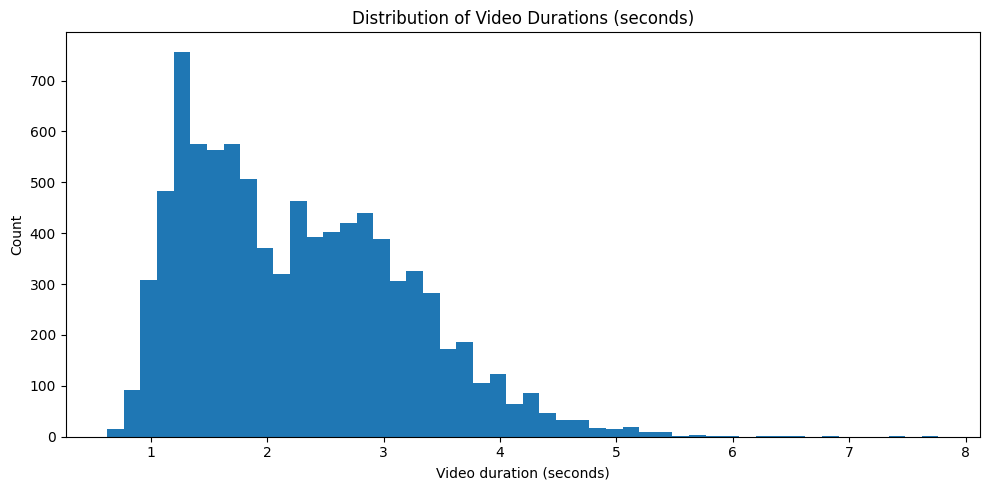

,video,filename,gloss,fps,total_frames,duration_sec,status
0,/content/drive/MyDrive/Consultant (1)/Colab_No...,69241.mp4,book,29.970030,75.0,2.502500,OK
1,/content/drive/MyDrive/Consultant (1)/Colab_No...,07069.mp4,book,23.976024,30.0,1.251250,OK
2,/content/drive/MyDrive/Consultant (1)/Colab_No...,07068.mp4,book,29.970000,68.0,2.268936,OK
3,/content/drive/MyDrive/Consultant (1)/Colab_No...,07070.mp4,book,30.003489,86.0,2.866333,OK
4,/content/drive/MyDrive/Consultant (1)/Colab_No...,07074.mp4,book,29.970000,41.0,1.368035,OK


In [6]:
# this is an explorotry step just to get a quick peek at the distribution . The EDA portion will cover this again

# Needed to restart runtime after the file was moved to a new directory
import matplotlib.pyplot as plt #matplot lib is for visulziation

df_length = pd.read_csv('/content/drive/MyDrive/Consultant/Colab_Notebooks/Obrown_Dissertation_NU_25/Metadata_WLASL/video_duration_report.csv')

# ==============================
# DISTRIBUTION PLOT
# ==============================
durations = df_length.loc[df_length["status"] == "OK", "duration_sec"].dropna().astype(float)

plt.figure(figsize=(10, 5))
plt.hist(durations, bins=50)
plt.xlabel("Video duration (seconds)")
plt.ylabel("Count")
plt.title("Distribution of Video Durations (seconds)")
plt.tight_layout()
plt.show()


df_length.head()

#3.3.4 *Detect Long and Short Outliers Reports*



In [23]:
#from google.colab import drive
#drive.mount('/content/drive')

In [ ]:
#Install Dependencies

#import cv2
#from pathlib import Path
#import pandas as pd
#import matplotlib.pyplot as plt

# ==============================
# CONFIG ( main folders)
# ==============================
ROOT_DIR = Path("/content/drive/MyDrive/Consultant/Colab_Notebooks/Obrown_Dissertation_NU_25/ASL_Raw_Data")
VIDEO_EXTS = {".mp4", ".mov", ".avi", ".mkv", ".webm"}

OUTPUT_LENGTH_CSV = ROOT_DIR / "video_length_report.csv"
OUTPUT_OUTLIERS_CSV = ROOT_DIR / "video_length_outliers_2sd.csv"
OUTPUT_SHORT_CSV = ROOT_DIR / "video_length_outliers_short_2sd.csv"
OUTPUT_LONG_CSV = ROOT_DIR / "video_length_outliers_long_2sd.csv"

OUTPUT_HIST_PNG = ROOT_DIR / "video_duration_hist.png" # Store Visuals
OUTPUT_BOX_PNG = ROOT_DIR / "video_duration_boxplot.png"


# ==============================
# Define Function Video duration extraction
# ==============================
def get_video_length_info(video_path: Path) -> dict:
    cap = cv2.VideoCapture(str(video_path))

    if not cap.isOpened():
        return {
            "video": str(video_path),
            "filename": video_path.name,
            "gloss": video_path.parent.name,
            "status": "Unreadable",
            "fps": None,
            "total_frames": None,
            "duration_sec": None,
        }

    fps = cap.get(cv2.CAP_PROP_FPS)
    frames = cap.get(cv2.CAP_PROP_FRAME_COUNT)

    # Robust duration: only compute if fps>0 and frames>0
    duration = (frames / fps) if (fps is not None and fps > 0 and frames is not None and frames > 0) else None

    cap.release()

    return {
        "video": str(video_path),
        "filename": video_path.name,
        "gloss": video_path.parent.name,
        "status": "OK",
        "fps": fps,
        "total_frames": frames,
        "duration_sec": duration,
    }


# ==============================
# Walk ALL subfolders
# ==============================
if not ROOT_DIR.exists():
    raise FileNotFoundError(
        f"ROOT_DIR does not exist: {ROOT_DIR}\n"
        "Confirm Drive is mounted and the path is correct."
    )

video_paths = [p for p in ROOT_DIR.rglob("*") if p.is_file() and p.suffix.lower() in VIDEO_EXTS]
results = [get_video_length_info(p) for p in video_paths]

df = pd.DataFrame(results)
df.to_csv(OUTPUT_LENGTH_CSV, index=False)

print(f"Found video files: {len(video_paths)}")
print(f"Rows in df:        {len(df)}")
print(f"Saved duration report: {OUTPUT_LENGTH_CSV}")
print(df["status"].value_counts(dropna=False))


# ==============================
# Outlier detection (±2 SD)
# ==============================
df_ok = df[df["status"].eq("OK")].copy()
df_ok["duration_sec"] = pd.to_numeric(df_ok["duration_sec"], errors="coerce")

dur = df_ok["duration_sec"].dropna()

length_mean = dur.mean()
length_std = dur.std()

lower = length_mean - 2 * length_std
upper = length_mean + 2 * length_std

short_outliers = df_ok[df_ok["duration_sec"] < lower].copy()
long_outliers  = df_ok[df_ok["duration_sec"] > upper].copy()
all_outliers   = pd.concat([short_outliers, long_outliers], ignore_index=True)

# Add thresholds for traceability
for dfx in (short_outliers, long_outliers, all_outliers):
    dfx["mean_sec"] = length_mean
    dfx["std_sec"] = length_std
    dfx["lower_2sd"] = lower
    dfx["upper_2sd"] = upper

# Save reports
all_outliers.to_csv(OUTPUT_OUTLIERS_CSV, index=False)
short_outliers.to_csv(OUTPUT_SHORT_CSV, index=False)
long_outliers.to_csv(OUTPUT_LONG_CSV, index=False)

print("\nDuration summary (OK videos only):")
print(f"Mean:  {length_mean:.4f} sec")
print(f"Std:   {length_std:.4f} sec")
print(f"Lower: {lower:.4f} sec (mean - 2*std)")
print(f"Upper: {upper:.4f} sec (mean + 2*std)")

print("\nOutlier counts:")
print(f"Short outliers: {len(short_outliers)}")
print(f"Long outliers:  {len(long_outliers)}")
print(f"All outliers:   {len(all_outliers)}")

print(f"\nSaved outliers:")
print(f"- {OUTPUT_SHORT_CSV}")
print(f"- {OUTPUT_LONG_CSV}")
print(f"- {OUTPUT_OUTLIERS_CSV}")

# Display a quick view
print("\nSample short outliers:")
print(short_outliers[["gloss", "filename", "duration_sec"]].sort_values("duration_sec").head(10))

print("\nSample long outliers:")
print(long_outliers[["gloss", "filename", "duration_sec"]].sort_values("duration_sec", ascending=False).head(10))


# ==============================
# Visualizations
# ==============================
# 1) Histogram
plt.figure(figsize=(10, 5))
plt.hist(dur, bins=50)
plt.axvline(lower, linestyle="--")
plt.axvline(upper, linestyle="--")
plt.xlabel("Video duration (seconds)")
plt.ylabel("Count")
plt.title("Video Duration Distribution (seconds) with ±2SD thresholds")
plt.tight_layout()
plt.savefig(OUTPUT_HIST_PNG, dpi=200)
plt.show()
print(f"\nSaved histogram: {OUTPUT_HIST_PNG}")

# 2) Box-and-whisker plot
plt.figure(figsize=(10, 2.5))
plt.boxplot(dur, vert=False, showfliers=True)
plt.xlabel("Video duration (seconds)")
plt.title("Box-and-Whisker Plot of Video Durations (seconds)")
plt.tight_layout()
plt.savefig(OUTPUT_BOX_PNG, dpi=200)
plt.show()
print(f"Saved boxplot: {OUTPUT_BOX_PNG}")


/tmp/ipython-input-1519390114.py:16: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  all_outliers = pd.concat([short_df, long_df], ignore_index=True)



=== Dashboard Summary ===
            Metric    Value
0     Total videos  302.000
1   Short outliers    0.000
2    Long outliers  302.000
3    Mean duration    4.660
4  Median duration    4.500
5          Std dev    0.535


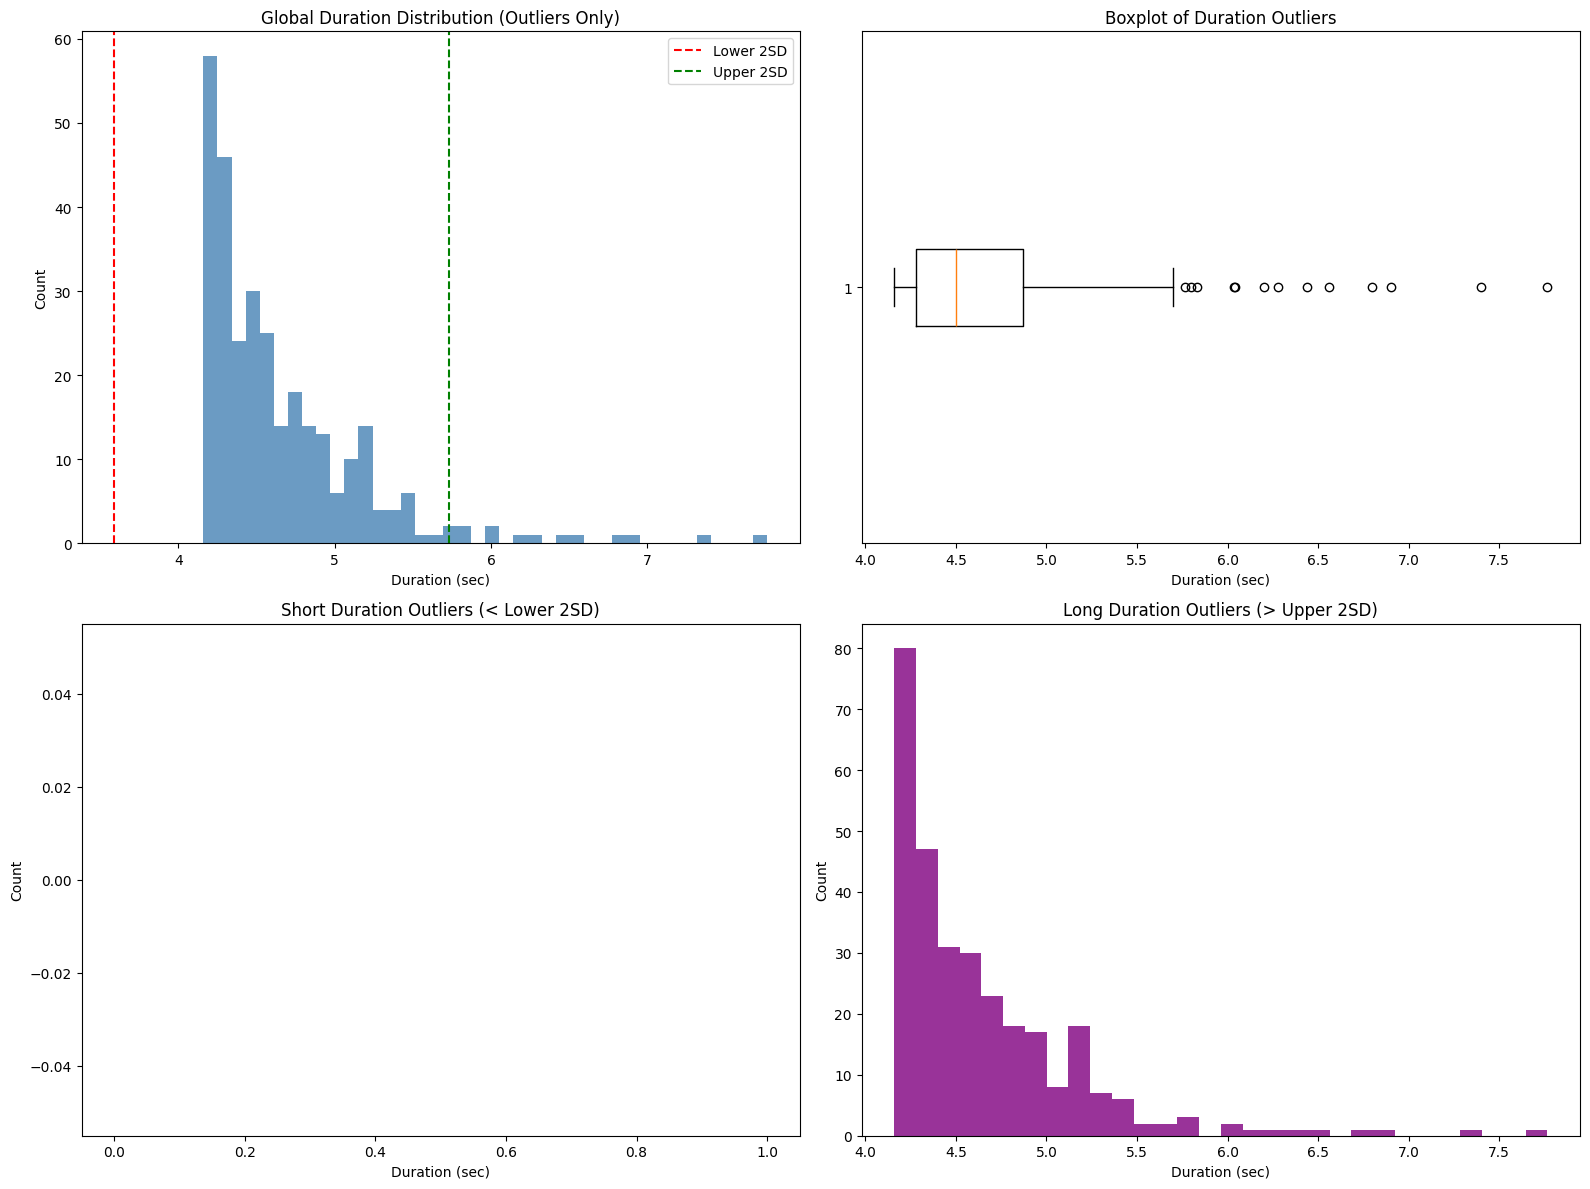

In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

# ==============================
# LOAD OUTLIER CSVs
# ==============================
short_csv = Path("/content/drive/MyDrive/Consultant/Colab_Notebooks/Obrown_Dissertation_NU_25/Metadata_WLASL/video_length_outliers_short_2sd.csv")
long_csv  = Path("/content/drive/MyDrive/Consultant/Colab_Notebooks/Obrown_Dissertation_NU_25/Metadata_WLASL/video_length_outliers_long_2sd.csv")

short_df = pd.read_csv(short_csv)
long_df  = pd.read_csv(long_csv)

# Combine for global stats
all_outliers = pd.concat([short_df, long_df], ignore_index=True)
dur = all_outliers["duration_sec"]

# Compute thresholds
lower = dur.mean() - 2 * dur.std()
upper = dur.mean() + 2 * dur.std()

# ==============================
# SUMMARY STATISTICS
# ==============================
summary = pd.DataFrame({
    "Metric": ["Total videos", "Short outliers", "Long outliers", "Mean duration", "Median duration", "Std dev"],
    "Value": [
        len(all_outliers),
        len(short_df),
        len(long_df),
        round(dur.mean(), 3),
        round(dur.median(), 3),
        round(dur.std(), 3)
    ]
})

print("\n=== Dashboard Summary ===")
print(summary)

# ==============================
# DASHBOARD VISUALS
# ==============================
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Panel 1 — Global histogram
axes[0, 0].hist(dur, bins=40, color="steelblue", alpha=0.8)
axes[0, 0].axvline(lower, linestyle="--", color="red", label="Lower 2SD")
axes[0, 0].axvline(upper, linestyle="--", color="green", label="Upper 2SD")
axes[0, 0].set_title("Global Duration Distribution (Outliers Only)")
axes[0, 0].set_xlabel("Duration (sec)")
axes[0, 0].set_ylabel("Count")
axes[0, 0].legend()

# Panel 2 — Boxplot
axes[0, 1].boxplot(dur, vert=False, showfliers=True)
axes[0, 1].set_title("Boxplot of Duration Outliers")
axes[0, 1].set_xlabel("Duration (sec)")

# Panel 3 — Short outliers histogram
axes[1, 0].hist(short_df["duration_sec"], bins=30, color="orange", alpha=0.8)
axes[1, 0].set_title("Short Duration Outliers (< Lower 2SD)")
axes[1, 0].set_xlabel("Duration (sec)")
axes[1, 0].set_ylabel("Count")

# Panel 4 — Long outliers histogram
axes[1, 1].hist(long_df["duration_sec"], bins=30, color="purple", alpha=0.8)
axes[1, 1].set_title("Long Duration Outliers (> Upper 2SD)")
axes[1, 1].set_xlabel("Duration (sec)")
axes[1, 1].set_ylabel("Count")

plt.tight_layout()
plt.show()

# 3.4.5  * Class Distribution Analysis



*   Use Duration reprot to find class distribution
*   Save this as both csv and json
*   analsyze class distribution just a preview



In [ ]:
#Install Dependencies

#import json
#from pathlib import Path
# import pandas as pd

# ==============================
# CONFIG Set Global Variables ( folders)
# ==============================
ROOT_DIR = Path("/content/drive/MyDrive/Consultant/Colab_Notebooks/Obrown_Dissertation_NU_25/ASL_Raw_Data")

INPUT_CSV = ROOT_DIR / "video_duration_report.csv"
OUTPUT_JSON = ROOT_DIR / "video_duration_report.json"

OUTPUT_CLASS_CSV = ROOT_DIR / "class_distribution_report.csv"
OUTPUT_CLASS_JSON = ROOT_DIR / "class_distribution_report.json"

# ==============================
# 1) Load duration report CSV
# ==============================
df = pd.read_csv(INPUT_CSV)

#  keep only usable videos for class counts

df_ok = df[df["status"].eq("OK")].copy()

# Ensure gloss is present
if "gloss" not in df_ok.columns:
    raise ValueError("Expected a 'gloss' column in video_duration_report.csv")

# ==============================
# 2) Convert CSV -> JSON
# ==============================
# Record-oriented JSON is convenient for downstream processing
records = df.to_dict(orient="records")
with open(OUTPUT_JSON, "w") as f:
    json.dump(records, f, indent=2)

print(f"Saved JSON to: {OUTPUT_JSON}")

# ==============================
# 3) Class distribution analysis
# ==============================
# Count videos per gloss
class_counts = (
    df_ok.groupby("gloss")
        .size()
        .reset_index(name="video_count")
        .sort_values("video_count", ascending=False)
)

# Save class distribution table
class_counts.to_csv(OUTPUT_CLASS_CSV, index=False)
print(f"Saved class distribution CSV to: {OUTPUT_CLASS_CSV}")

# Also save class distribution as JSON
with open(OUTPUT_CLASS_JSON, "w") as f:
    json.dump(class_counts.to_dict(orient="records"), f, indent=2)

print(f"Saved class distribution JSON to: {OUTPUT_CLASS_JSON}")

print("\nTop classes:")
print(class_counts.head(10))

print("\nBottom classes:")
print(class_counts.tail(10))

# 3.4.6 *Low Sample Classes*

This script:
• 	Loads your class distribution
• 	Summarizes how many videos each gloss has
• 	Identifies glosses with ≤ 2 videos
• 	Saves those low‑sample glosses to a CSV
• 	Prints how imbalanced your dataset is

It’s a quality‑control step to help determine  whether the dataset is suitable for training a sign‑language recognition model.


In [ ]:
import pandas as pd
from pathlib import Path

# ==============================
# CONFIG
# ==============================
ROOT_DIR = Path("/content/drive/MyDrive/Consultant/Colab_Notebooks/Obrown_Dissertation_NU_25/ASL_Raw_Data")

CLASS_DIST_CSV = ROOT_DIR / "class_distribution_report.csv"
LOW_SAMPLE_CSV = ROOT_DIR / "low_sample_classes.csv"

# ==============================
# LOAD CLASS DISTRIBUTION
# ==============================
df = pd.read_csv(CLASS_DIST_CSV)

# ==============================
# DESCRIPTIVE STATISTICS
# ==============================
print("\n=== Class Distribution Summary ===")
print(df["video_count"].describe())

# Extra clarity for reporting
print("\nAdditional diagnostics:")
print(f"Total classes: {len(df)}")
print(f"Mean samples per class: {df['video_count'].mean():.2f}")
print(f"Median samples per class: {df['video_count'].median():.2f}")
print(f"Min samples: {df['video_count'].min()}")
print(f"Max samples: {df['video_count'].max()}")

# ==============================
# LOW-SAMPLE CLASS DETECTION
# ==============================
LOW_SAMPLE_THRESHOLD = 2

low_sample = df[df["video_count"] <= LOW_SAMPLE_THRESHOLD].copy()

print("\n=== Low-Sample Classes (\u2264 2 videos) ===")
print(low_sample)

# Save for later filtering or reporting
low_sample.to_csv(LOW_SAMPLE_CSV, index=False)
print(f"\nSaved low-sample class report to: {LOW_SAMPLE_CSV}")

# ==============================
# OPTIONAL: Proportion of dataset affected
# ==============================
pct_low = (len(low_sample) / len(df)) * 100
print(f"\nPercentage of low-sample classes: {pct_low:.2f}%")

Low Sample cases Visual Preview:

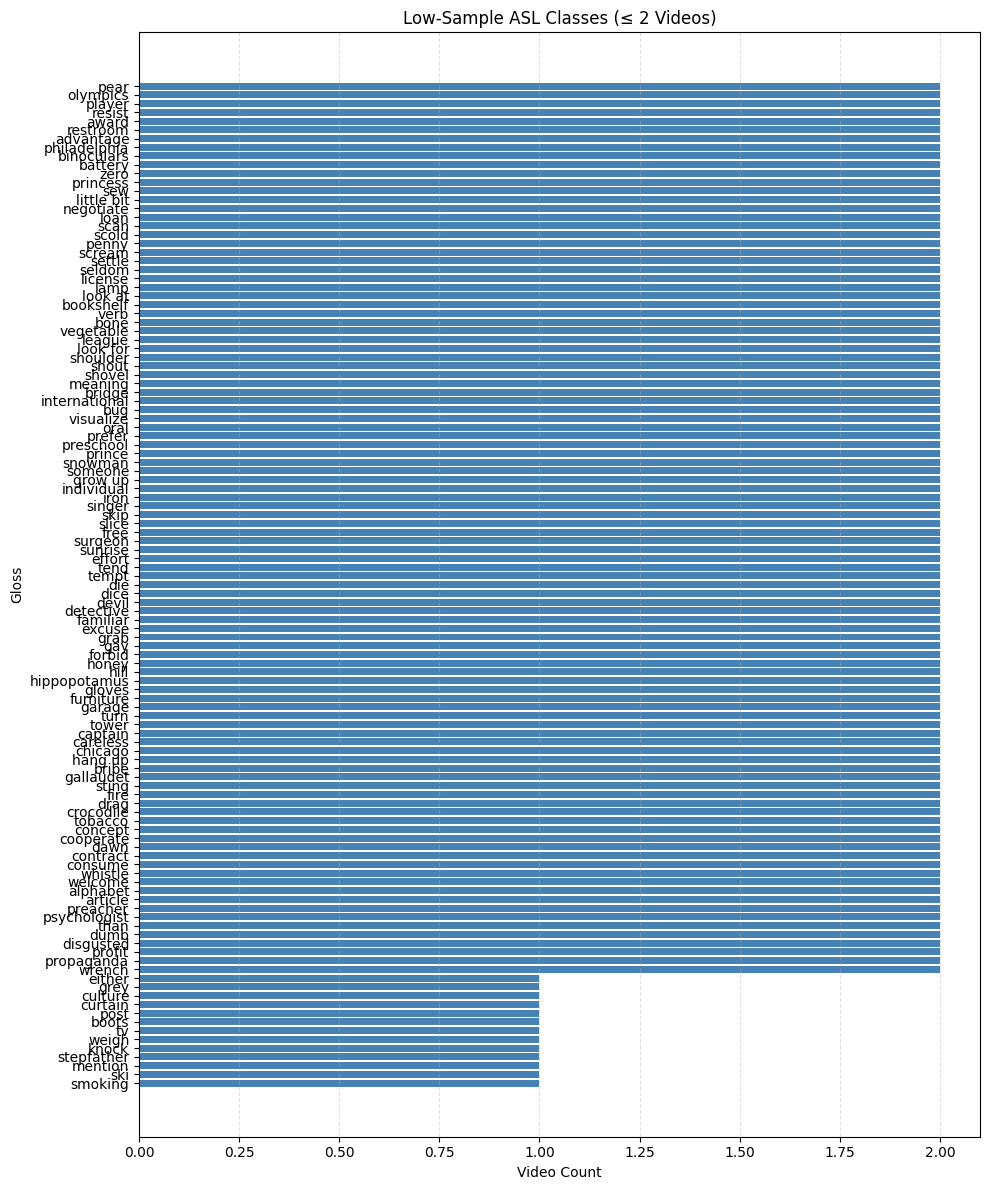

In [7]:
#Low Sample Cases Visual quick view

import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Load the CSV
csv_path = Path("/content/drive/MyDrive/Consultant/Colab_Notebooks/Obrown_Dissertation_NU_25/Metadata_WLASL/low_sample_classes.csv")
df = pd.read_csv(csv_path)

# Sort by video_count for a cleaner plot
df = df.sort_values("video_count")

# Plot
plt.figure(figsize=(10, 12))
plt.barh(df["gloss"], df["video_count"], color="steelblue")

plt.xlabel("Video Count")
plt.ylabel("Gloss")
plt.title("Low‑Sample ASL Classes (≤ 2 Videos)")
plt.grid(axis="x", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

#3.4.7 *Video Resolution & Aspect Ratio*

In [ ]:
import cv2
from pathlib import Path
import pandas as pd
import math

# ==============================
# CONFIG
# ==============================
ROOT_DIR = Path("/content/drive/MyDrive/Consultant/Colab_Notebooks/Obrown_Dissertation_NU_25/ASL_Raw_Data")
VIDEO_EXTS = {".mp4", ".mov", ".avi", ".mkv", ".webm"}
OUTPUT_CSV = ROOT_DIR / "video_resolution_aspect_report.csv"

# ==============================
# HELPERS
# ==============================
def simplify_ratio(width: int, height: int) -> str:
    if width is None or height is None or width <= 0 or height <= 0:
        return None
    g = math.gcd(width, height)
    return f"{width // g}:{height // g}"

# ==============================
# FUNCTION
# ==============================
def check_resolution(video_path: Path) -> dict:
    cap = cv2.VideoCapture(str(video_path))

    if not cap.isOpened():
        return {
            "video": str(video_path),
            "filename": video_path.name,
            "gloss": video_path.parent.name,
            "status": "Unreadable",
            "width": None,
            "height": None,
            "aspect_ratio": None,
            "aspect_ratio_simplified": None,
        }

    width  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH) or 0)
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT) or 0)
    cap.release()

    if width <= 0 or height <= 0:
        return {
            "video": str(video_path),
            "filename": video_path.name,
            "gloss": video_path.parent.name,
            "status": "Missing dimensions",
            "width": width if width > 0 else None,
            "height": height if height > 0 else None,
            "aspect_ratio": None,
            "aspect_ratio_simplified": None,
        }

    aspect_ratio = width / height

    return {
        "video": str(video_path),
        "filename": video_path.name,
        "gloss": video_path.parent.name,
        "status": "OK",
        "width": width,
        "height": height,
        "aspect_ratio": aspect_ratio,
        "aspect_ratio_simplified": simplify_ratio(width, height),
    }

# ==============================
# WALK ALL SUBFOLDERS
# ==============================
if not ROOT_DIR.exists():
    raise FileNotFoundError(
        f"ROOT_DIR does not exist: {ROOT_DIR}\n"
        "If you're in Colab, confirm Google Drive is mounted and the path is correct."
    )

video_paths = [p for p in ROOT_DIR.rglob("*") if p.is_file() and p.suffix.lower() in VIDEO_EXTS]
results = [check_resolution(p) for p in video_paths]

df = pd.DataFrame(results)

# Save
df.to_csv(OUTPUT_CSV, index=False)

print(f"Found videos: {len(video_paths)}")
print(f"Rows in df:  {len(df)}")
print(f"Saved report to: {OUTPUT_CSV}")

# Quick summary tables (optional but useful)
print("\nTop aspect ratios:")
print(df[df["status"].eq("OK")]["aspect_ratio_simplified"].value_counts().head(10))

print("\nTop resolutions:")
print((df[df["status"].eq("OK")]["width"].astype(str) + "x" + df[df["status"].eq("OK")]["height"].astype(str))
      .value_counts().head(10))

df.head()


#3.4.8 *Lightning & Brightness Variablility*

In [ ]:
#Install Dependencies

#import cv2
import numpy as np  # numpy for numbers this csv will require number mangment
#import pandas as pd
#from pathlib import Path

# ==============================
# CONFIG - Again configure folders these are global varaibles
# ==============================
ROOT_DIR = Path("/content/drive/MyDrive/Consultant/Colab_Notebooks/Obrown_Dissertation_NU_25/ASL_Raw_Data")
VIDEO_EXTS = {".mp4", ".mov", ".avi", ".mkv", ".webm"}

OUTPUT_CSV = ROOT_DIR / "video_brightness_report.csv"

# Number of frames to sample evenly across each video
SAMPLE_FRAMES = 10


# ==============================
# FUNCTION-- Define the brightness function
# ==============================
def check_brightness(video_path: Path, sample_frames=10):
    cap = cv2.VideoCapture(str(video_path)) # open cvs

    if not cap.isOpened():
        return {
            "video": str(video_path),
            "filename": video_path.name,
            "gloss": video_path.parent.name,
            "status": "Unreadable",
            "brightness_mean": None,
            "brightness_std": None,
        }

    frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    if frame_count <= 0:
        cap.release()
        return {
            "video": str(video_path),
            "filename": video_path.name,
            "gloss": video_path.parent.name,
            "status": "No frames",
            "brightness_mean": None,
            "brightness_std": None,
        }

    # Evenly spaced frame indices
    indices = np.linspace(0, frame_count - 1, min(sample_frames, frame_count)).astype(int)

    brightness_values = [] # store values in empty list

    #loop over the data

    for idx in indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
        ret, frame = cap.read()

        if not ret:
            continue

        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        brightness_values.append(gray.mean())

    cap.release()

    if not brightness_values:
        return {
            "video": str(video_path),
            "filename": video_path.name,
            "gloss": video_path.parent.name,
            "status": "No valid frames",
            "brightness_mean": None,
            "brightness_std": None,
        }

    return {
        "video": str(video_path),
        "filename": video_path.name,
        "gloss": video_path.parent.name,
        "status": "OK",
        "brightness_mean": float(np.mean(brightness_values)),
        "brightness_std": float(np.std(brightness_values)),
    }


# ==============================
# PROCESS ALL VIDEOS
# ==============================
if not ROOT_DIR.exists():
    raise FileNotFoundError(
        f"ROOT_DIR does not exist: {ROOT_DIR}\n"
        "Make sure Google Drive is mounted correctly."
    )

video_paths = [p for p in ROOT_DIR.rglob("*") if p.is_file() and p.suffix.lower() in VIDEO_EXTS]

results = [check_brightness(p, SAMPLE_FRAMES) for p in video_paths]

df = pd.DataFrame(results)

df.to_csv(OUTPUT_CSV, index=False)

print(f"Processed videos: {len(df)}")
print(f"Saved brightness report: {OUTPUT_CSV}")

# ==============================
# QUICK DIAGNOSTICS
# ==============================
print("\nBrightness summary (OK videos only):")
print(df[df["status"] == "OK"]["brightness_mean"].describe())

print("\nHighest variability videos:")
print(
    df[df["status"] == "OK"]
    .sort_values("brightness_std", ascending=False)
    .head(10)[["gloss", "filename", "brightness_std"]]
)

df.head()


In [ ]:
# google had problmes with setting up media pipe this is a shell command line
!pip install -U mediapipe==0.10.31





In [ ]:
# more of the mediapeipe set up
!pip uninstall -y mediapipe
!pip install mediapipe==0.10.14



In [ ]:
#meida pipe tasks need to be set up this was a quick fix from the AI in google colab
from mediapipe.tasks import python
from mediapipe.tasks.python import vision


This block is setting up MediaPipe’s Hand Landmarker model so you can run hand‑pose detection on your ASL videos. Each line plays a specific role in loading the model and creating a detector object you can use later to process frames.


In [ ]:
# Mediapip3e install
from mediapipe.tasks import python
from mediapipe.tasks.python import vision
from pathlib import Path

# Define the correct ROOT_DIR, similar to where the model was downloaded
ROOT_DIR = Path("/content/drive/MyDrive/Consultant/Colab_Notebooks/Obrown_Dissertation_NU_25/ASL_Raw_Data")
model_path = ROOT_DIR / 'hand_landmarker.task'

base_options = python.BaseOptions(model_asset_path=str(model_path))
options = vision.HandLandmarkerOptions(base_options=base_options, num_hands=2)
detector = vision.HandLandmarker.create_from_options(options)


In [ ]:
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision

# Base options for MediaPipe tasks
base_options = python.BaseOptions(model_asset_path='hand_landmarker.task')

# Create a HandLandmarker object.
# This object is typically created once and reused for multiple frames.
# The model_asset_path needs to point to the actual model file.
# For now, we'll initialize it, but you might need to download the model.
# You can often find these models in the MediaPipe documentation or examples.
mp_hands = vision.HandLandmarker.create_from_options(
    vision.HandLandmarkerOptions(base_options=base_options, running_mode=vision.RunningMode.IMAGE))


In [ ]:
import mediapipe as mp
print("MediaPipe version:", mp.__version__)
print("Hands module:", mp.solutions.hands)


#3.4.9 *Handedness Report*

In [ ]:
# These dependenceis are required mediapipe is difficut to get started in google colab but the AI can help with the set up .
import cv2
import numpy as np
import pandas as pd
from pathlib import Path
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision

# ==============================
# CONFIG- Global Variables
# ==============================
ROOT_DIR = Path("/content/drive/MyDrive/Consultant/Colab_Notebooks/Obrown_Dissertation_NU_25/ASL_Raw_Data")
VIDEO_EXTS = {".mp4", ".mov", ".avi", ".mkv", ".webm"}
OUTPUT_CSV = ROOT_DIR / "video_quality_duration_hand_report.csv"

# EDA flag defaults (starting points)
AVAILABILITY_MIN = 0.70          # flag if availability_pct < this
STABILITY_MAX_JITTER = 0.02      # flag if stability_mean_jitter_norm > this
MIN_DETECTED_FRAMES_FOR_STABILITY = 3  # require >=3 detected frames to trust stability metric


#====== IMPORTANT NOTICE- Colab has problems with Meidapipe set up but once its running its fine
 #MediaPipe HandLandmarker setup (using the new API)
# You might need to download the 'hand_landmarker.task' model first.
# For example, from: https://developers.google.com/mediapipe/solutions/vision/hand_landmarker#models
# And place it in a location accessible by your Colab environment.

# Download the hand_landmarker.task model if it doesn't exist
model_path = ROOT_DIR / 'hand_landmarker.task'
if not model_path.exists():
    print(f"Downloading hand_landmarker.task to {model_path}...")
    !wget -O {model_path} https://storage.googleapis.com/mediapipe-models/hand_landmarker/hand_landmarker/float16/1/hand_landmarker.task
    print("Download complete.")

base_options = python.BaseOptions(model_asset_path=str(model_path))
hand_landmarker_options = vision.HandLandmarkerOptions(
    base_options=base_options,
    running_mode=vision.RunningMode.IMAGE,
    num_hands=2,
    min_hand_detection_confidence=0.5
)


def sample_frame_indices(total_frames: int, sample_frames: int) -> np.ndarray:
    """Evenly sample frame indices across the clip."""
    if total_frames is None or total_frames <= 0:
        return np.array([], dtype=int)
    n = min(sample_frames, total_frames)
    return np.linspace(0, total_frames - 1, n).astype(int)


def compute_duration_info(cap: cv2.VideoCapture):
    fps = cap.get(cv2.CAP_PROP_FPS)
    frames = cap.get(cv2.CAP_PROP_FRAME_COUNT)
    fps = float(fps) if fps is not None else None
    frames = float(frames) if frames is not None else None

    duration = (frames / fps) if (fps is not None and fps > 0 and frames is not None and frames > 0) else None
    return fps, frames, duration


def detect_hand_availability_and_stability(video_path: Path, sample_frames: int = 20):
    """
    Availability:
      - number_of_frames_with_full_hand_landmarks / frames_sampled
    Stability:
      - mean normalized jitter across all landmarks (frame-to-frame) for the best hand
      - wrist normalized jitter (landmark 0) for the best hand

    Normalized jitter is computed in image-relative coordinates (x,y from MediaPipe are already normalized).
    Lower is more stable.
    """
    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        return {
            "frames_sampled": 0,
            "number_of_frames_with_full_hand_landmarks": 0,
            "availability_pct": None,
            "stability_mean_jitter_norm": None,
            "stability_wrist_jitter_norm": None,
        }

    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT)) if cap.get(cv2.CAP_PROP_FRAME_COUNT) else 0
    idxs = sample_frame_indices(total_frames, sample_frames)
    if len(idxs) == 0:  # No frames to sample
        cap.release()
        return {
            "frames_sampled": 0,
            "number_of_frames_with_full_hand_landmarks": 0,
            "availability_pct": None,
            "stability_mean_jitter_norm": None,
            "stability_wrist_jitter_norm": None,
        }

    landmark_series = []  # list of (21,2) arrays in normalized coordinates
    detected_frames = 0

    # Create a new HandLandmarker instance for each video if running in IMAGE mode
    # or consider changing to VIDEO mode if processing consecutive frames is feasible.
    with vision.HandLandmarker.create_from_options(hand_landmarker_options) as hand_landmarker:
        for idx in idxs:
            cap.set(cv2.CAP_PROP_POS_FRAMES, int(idx))
            ret, frame = cap.read()
            if not ret or frame is None:
                continue

            # Convert the frame to MediaPipe Image format
            mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
            detection_result = hand_landmarker.detect(mp_image)

            if not detection_result.hand_landmarks:
                continue

            # Choose one hand per frame (best by mean visibility if available)
            best = None
            best_score = -1.0

            for hand_lms in detection_result.hand_landmarks:
                pts = hand_lms
                if len(pts) != 21: # Ensure 21 landmarks for a full hand
                    continue

                # For mediapipe.tasks, visibility is not directly in HandLandmarker.Landmark
                # If visibility is crucial, it might need to be inferred or custom scored.
                # For simplicity here, we'll assume all detected landmarks are 'visible' for scoring.
                # If multiple hands, pick the first one for now.
                if best is None: # Just take the first detected hand for simplicity for now
                    best = pts
                    break

            if best is None:
                continue

            detected_frames += 1

            # Convert to (21,2) normalized array
            arr = np.array([[p.x, p.y] for p in best], dtype=float)
            landmark_series.append(arr)

    cap.release()

    frames_sampled = len(idxs)
    availability_pct = (detected_frames / frames_sampled) if frames_sampled > 0 else None

    # Stability: compute frame-to-frame jitter only if we have >= 2 detected frames with landmarks
    if len(landmark_series) >= 2:
        series = np.stack(landmark_series, axis=0)        # (T,21,2) normalized
        diffs = np.diff(series, axis=0)                   # (T-1,21,2)
        step_dist = np.linalg.norm(diffs, axis=2)         # (T-1,21)

        stability_mean_jitter_norm = float(np.mean(step_dist))          # mean across time & landmarks
        stability_wrist_jitter_norm = float(np.mean(step_dist[:, 0]))   # landmark 0 = wrist
    else:
        stability_mean_jitter_norm = None
        stability_wrist_jitter_norm = None

    return {
        "frames_sampled": frames_sampled,
        "number_of_frames_with_full_hand_landmarks": detected_frames,
        "availability_pct": availability_pct,
        "stability_mean_jitter_norm": stability_mean_jitter_norm,
        "stability_wrist_jitter_norm": stability_wrist_jitter_norm,
    }


def process_video(video_path: Path, sample_frames: int = 20):
    # Basic open/read checks + duration
    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        return {
            "video": str(video_path),
            "filename": video_path.name,
            "gloss": video_path.parent.name,
            "status": "Unreadable (cannot open)",
            "fps": None,
            "total_frames": None,
            "duration_sec": None,
            "frames_sampled": 0,
            "number_of_frames_with_full_hand_landmarks": 0,
            "availability_pct": None,
            "stability_mean_jitter_norm": None,
            "stability_wrist_jitter_norm": None,
        }

    fps, frames, duration = compute_duration_info(cap)

    # First-frame readability check (corruption signal)
    ret, frame0 = cap.read()
    cap.release()
    if not ret or frame0 is None: # If first frame is unreadable, often signals corruption.
        base = {
            "video": str(video_path),
            "filename": video_path.name,
            "gloss": video_path.parent.name,
            "status": "Corrupted (cannot read first frame)",
            "fps": fps,
            "total_frames": frames,
            "duration_sec": duration,
        }
        base.update({ # Set hand stats to None/0 if first frame fails
            "frames_sampled": 0,
            "number_of_frames_with_full_hand_landmarks": 0,
            "availability_pct": None,
            "stability_mean_jitter_norm": None,
            "stability_wrist_jitter_norm": None,
        })
        return base

    # Hand availability + stability (uses its own capture)
    hand_stats = detect_hand_availability_and_stability(video_path, sample_frames=sample_frames)

    out = {
        "video": str(video_path),
        "filename": video_path.name,
        "gloss": video_path.parent.name,
        "status": "OK",
        "fps": fps,
        "total_frames": frames,
        "duration_sec": duration,
    }
    out.update(hand_stats)

    # ==============================
    # EDA FLAGS (no pipeline change)
    # ==============================
    availability = out.get("availability_pct", None)
    mean_jitter = out.get("stability_mean_jitter_norm", None)
    detected = out.get("number_of_frames_with_full_hand_landmarks", 0)

    # Flag 1: low availability
    out["flag_low_hand_availability"] = (
        (availability is None) or (availability < AVAILABILITY_MIN)
    )

    # Flag 2: unstable landmarks
    # If we don't have enough detected frames to compute stability reliably, flag it.
    out["flag_unstable_hand_landmarks"] = (
        (mean_jitter is None) or (detected < MIN_DETECTED_FRAMES_FOR_STABILITY) or (mean_jitter > STABILITY_MAX_JITTER)
    )

    # Optional: a single combined "bad clip" flag (often helpful in EDA)
    out["flag_problematic_clip"] = out["flag_low_hand_availability"] or out["flag_unstable_hand_landmarks"]

    return out



# ==============================
# WALK ALL SUBFOLDERS (RECURSIVE)
# ==============================
if not ROOT_DIR.exists():
    raise FileNotFoundError(
        f"ROOT_DIR does not exist: {ROOT_DIR}\n"
        "In Colab, confirm Drive is mounted and the path matches exactly."
    )

video_paths = [p for p in ROOT_DIR.rglob("*") if p.is_file() and p.suffix.lower() in VIDEO_EXTS]

results = []
for p in video_paths:
    results.append(process_video(p, sample_frames=20))

df = pd.DataFrame(results)

print(df[["flag_low_hand_availability","flag_unstable_hand_landmarks","flag_problematic_clip"]].mean().rename("flag_rate"))


# Verify full processing coverage
print(f"Found video files on disk: {len(video_paths)}")
print(f"Rows in report dataframe:  {len(df)}")

df.to_csv(OUTPUT_CSV, index=False)
print(f"Saved combined report to: {OUTPUT_CSV}")

df.head()


#3.4.10  *Extract Signer Metadata: Signer Variability Assessment*

*   The metadata JSON file (WLASL_v0.3.json) contains "signer" labels for a subset.




In [ ]:
#Mount drive
#from google.colab import drive
#drive.mount('/content/drive')

from pathlib import Path

# Your intended path
target = Path("/content/drive/MyDrive/WLASL/start_kit/WLASL_v0.3.json")

if target.exists():
    json_path = target
else:
    # Robust search: look for the file anywhere under MyDrive
    candidates = list(Path("/content/drive/MyDrive").rglob("WLASL_v0.3.json"))
    if not candidates:
        raise FileNotFoundError(
            "Could not find WLASL_v0.3.json under /content/drive/MyDrive.\n"
            "Try checking the exact filename/folder in Drive."
        )
    json_path = candidates[0]  # take the first match

print("Using JSON file at:", json_path)


* Signer data can be extractred from the json file

In [ ]:
import json
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

out_csv = json_path.parent / "WLASL_v0.3_signer_id.csv"
out_png = json_path.parent / "WLASL_v0.3_signer_id_distribution.png"

with json_path.open("r", encoding="utf-8") as f:
    data = json.load(f)

rows = []

def add_row(signer_id, ctx):
    rows.append({
        "signer_id": signer_id,
        "gloss": ctx.get("gloss"),
        "video_id": ctx.get("video_id"),
        "instance_id": ctx.get("instance_id"),
        "split": ctx.get("split"),
    })

def walk(obj, ctx):
    if isinstance(obj, dict):
        new_ctx = dict(ctx)
        # Carry common context keys if present
        for k in ["gloss", "video_id", "instance_id", "split"]:
            if k in obj and obj.get(k) is not None:
                new_ctx[k] = obj.get(k)

        # Record signer_id whenever it appears
        if "signer_id" in obj:
            add_row(obj.get("signer_id"), new_ctx)

        for v in obj.values():
            walk(v, new_ctx)

    elif isinstance(obj, list):
        for item in obj:
            walk(item, ctx)

walk(data, {})

df = pd.DataFrame(rows)
df = df[df["signer_id"].notna()].copy()

# Save CSV
df.to_csv(out_csv, index=False)
print(f"Saved CSV: {out_csv}")
print(f"Rows extracted: {len(df)}")

# Distribution
counts = df["signer_id"].value_counts().reset_index()
counts.columns = ["signer_id", "count"]

print("\nTop 10 signer_ids:")
print(counts.head(10).to_string(index=False))

# Plot top 20
top_n = 20
top = counts.head(top_n)

plt.figure(figsize=(12, 6))
plt.bar(top["signer_id"].astype(str), top["count"])
plt.xticks(rotation=45, ha="right")
plt.xlabel("signer_id (top 20)")
plt.ylabel("Count")
plt.title("WLASL v0.3: signer_id Frequency (Top 20)")
plt.tight_layout()
plt.savefig(out_png, dpi=200)
plt.show()

print(f"Saved plot: {out_png}")

df.head()


* Signer visual- sneep peak

In [ ]:
import matplotlib.pyplot as plt

# Count how many samples per signer
signer_counts = df["signer_id"].value_counts()

# Histogram of signer frequencies
plt.figure(figsize=(10, 6))
plt.hist(signer_counts, bins=30)

plt.xlabel("Number of samples per signer")
plt.ylabel("Number of signers")
plt.title("WLASL: Distribution of Samples per Signer")
plt.grid(np.False_)

hist_path = json_path.parent / "WLASL_signer_count_histogram.png"
plt.tight_layout()
plt.savefig(hist_path, dpi=200)
plt.show()

print(f"Histogram saved to: {hist_path}")


* Preview of signers

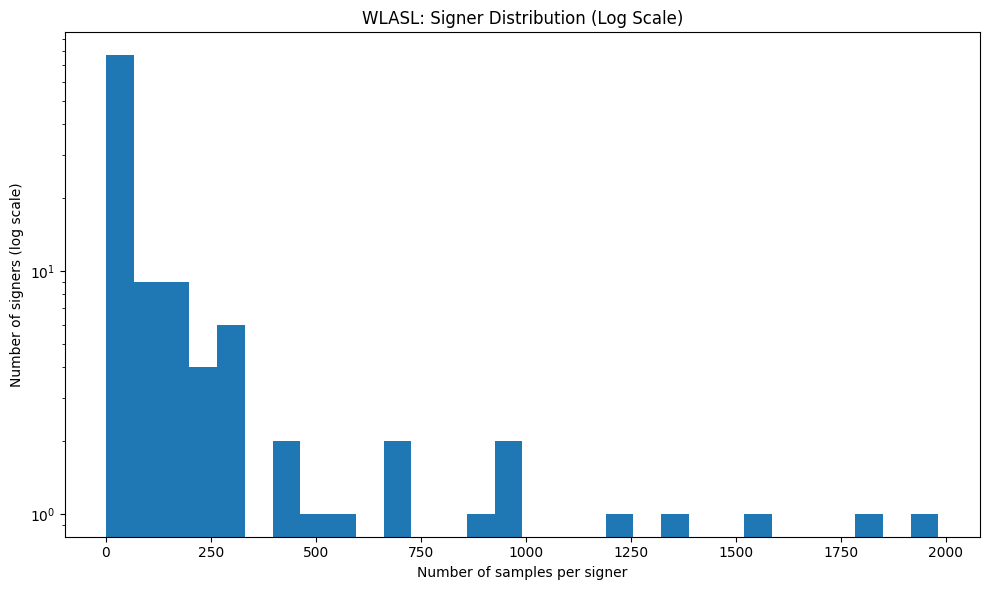

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

# Load the signer CSV
csv_path = Path("/content/drive/MyDrive/WLASL/start_kit/WLASL_v0.3_signer_id.csv")
df = pd.read_csv(csv_path)

# Count how many samples each signer has
signer_counts = df["signer_id"].value_counts()

# Plot histogram
plt.figure(figsize=(10, 6))
plt.hist(signer_counts, bins=30, log=True)

plt.xlabel("Number of samples per signer")
plt.ylabel("Number of signers (log scale)")
plt.title("WLASL: Signer Distribution (Log Scale)")

plt.grid(False)
plt.tight_layout()

# Save next to the CSV
plt.savefig(csv_path.parent / "WLASL_signer_count_histogram_log.png", dpi=200)

plt.show()


#3.4.11  **Motion Speed Variation**

*For each frame:*


*   Extract hand or pose landmarks
*   Compute Euclidean distance between keypoints across consecutive frames
*   Sum these distances → motion magnitude
*   Divide by number of frames → average motion speed










** Capture the speed of the hands*




In [ ]:
#Install Dependenices
import cv2
import mediapipe as mp
import numpy as np

# load mediapipe hands moduel
mp_hands = mp.solutions.hands

#define custome fuction
def compute_motion_speed(video_path):
    cap = cv2.VideoCapture(video_path) #  open video
    if not cap.isOpened():
        return None

    prev_landmarks = None
    frame_speeds = []

    with mp_hands.Hands(
        static_image_mode=False,
        max_num_hands=1,
        min_detection_confidence=0.5,
        min_tracking_confidence=0.5
    ) as hands: #initiualize Meidapipe

        while True:
            ret, frame = cap.read() # process each frame
            if not ret:
                break

            results = hands.process(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))

            if not results.multi_hand_landmarks:
                continue

            lm = results.multi_hand_landmarks[0]
            coords = np.array([(p.x, p.y) for p in lm.landmark]) # extract hand landmarks

            #compute motion between frames

            if prev_landmarks is not None:
                diff = coords - prev_landmarks
                frame_motion = np.linalg.norm(diff, axis=1).mean()
                frame_speeds.append(frame_motion)

            prev_landmarks = coords # updates previous landmarks

    cap.release()

    #Final output

    if len(frame_speeds) == 0:
        return None

    return float(np.mean(frame_speeds))


**motion‑speed function built earlier and applying it to every video in the  ASL_Raw_Data directory, then saving the results into a CSV.**


In [ ]:
from pathlib import Path
import pandas as pd

ROOT_DIR = Path("/content/drive/MyDrive/Consultant/Colab_Notebooks/Obrown_Dissertation_NU_25/ASL_Raw_Data")
VIDEO_EXTS = {".mp4", ".mov", ".avi", ".mkv"} # these videos only has mp4

rows = []

for path in ROOT_DIR.rglob("*"):
    if path.suffix.lower() in VIDEO_EXTS:
        speed = compute_motion_speed(path)
        rows.append({
            "video": str(path),
            "filename": path.name,
            "gloss": path.parent.name,
            "motion_speed": speed
        })

df_speed = pd.DataFrame(rows)
df_speed = df_speed.dropna()


df_speed.to_csv(
    ROOT_DIR / "motion_speed_report.csv",
    index=False
)
print(f"Processed {len(df_speed)} videos")
df_speed.head()




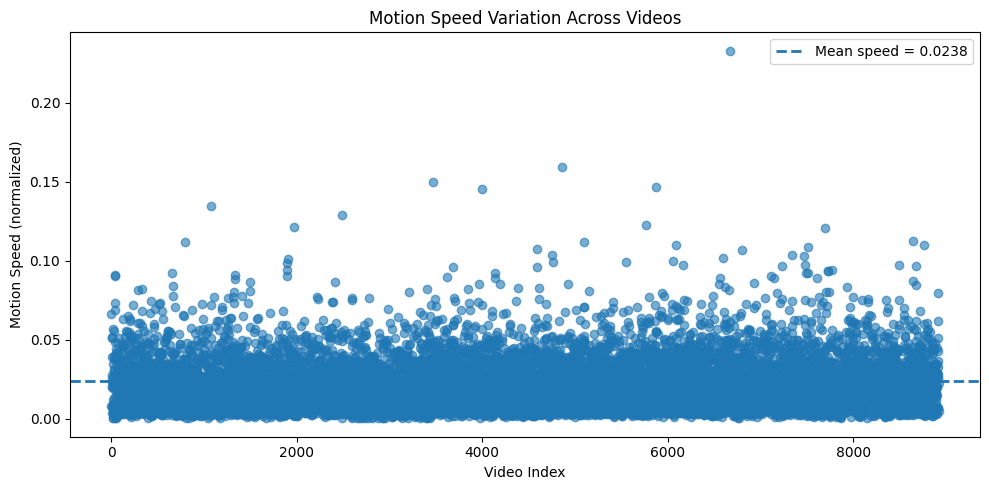

In [10]:
import matplotlib.pyplot as plt
import numpy as np

df_speed = pd.read_csv('/content/drive/MyDrive/Consultant/Colab_Notebooks/Obrown_Dissertation_NU_25/Metadata_WLASL/motion_speed_report.csv')
speeds = df_speed["motion_speed"]

mean_speed = speeds.mean()

plt.figure(figsize=(10, 5))
plt.scatter(range(len(speeds)), speeds, alpha=0.6)

# Mean line
plt.axhline(
    y=mean_speed,
    linestyle="--",
    linewidth=2,
    label=f"Mean speed = {mean_speed:.4f}"
)

plt.xlabel("Video Index")
plt.ylabel("Motion Speed (normalized)")
plt.title("Motion Speed Variation Across Videos")
plt.legend()

# IMPORTANT: no grid lines
plt.grid(False)

plt.tight_layout()
plt.show()


In [11]:
import pandas as pd
from pathlib import Path

motion_csv = Path("/content/drive/MyDrive/Consultant/Colab_Notebooks/Obrown_Dissertation_NU_25/ASL_Raw_Data")

df_motion = pd.read_csv(motion_csv / "motion_speed_report.csv")

print(f"Loaded {len(df_motion)} motion records")
df_motion.head()

Loaded 8923 motion records


,video,filename,gloss,motion_speed
0,/content/drive/MyDrive/Consultant/Colab_Notebo...,63612.mp4,without,0.007661
1,/content/drive/MyDrive/Consultant/Colab_Notebo...,63609.mp4,without,0.066445
2,/content/drive/MyDrive/Consultant/Colab_Notebo...,63610.mp4,without,0.020224
3,/content/drive/MyDrive/Consultant/Colab_Notebo...,63607.mp4,without,0.027489
4,/content/drive/MyDrive/Consultant/Colab_Notebo...,63608.mp4,without,0.038910


In [12]:
# Lower 5% = slow motion
threshold_low = df_motion["motion_speed"].quantile(0.05)

slow_videos = df_motion[
    df_motion["motion_speed"] <= threshold_low
].copy()


In [13]:
# Percentile thresholds
low_thresh = df_speed["motion_speed"].quantile(0.05)
high_thresh = df_speed["motion_speed"].quantile(0.95)

def classify_motion(speed):
    if speed <= low_thresh:
        return "slow"
    elif speed >= high_thresh:
        return "fast"
    else:
        return "normal"

df_speed["motion_category"] = df_speed["motion_speed"].apply(classify_motion)


In [ ]:
threshold_high = df_motion["motion_speed"].quantile(0.95)
fast_videos = df_motion[df_motion["motion_speed"] >= threshold_high]


In [14]:
gloss_speed = df_motion.groupby("gloss")["motion_speed"].agg(["mean", "std", "count"])
print(gloss_speed.head())

             mean       std  count
gloss                             
a        0.015617  0.013372      3
a lot    0.023899  0.019554      6
abdomen  0.005629  0.006037      4
able     0.022029  0.008547      4
about    0.015936  0.016805      4


#3.4.12  *Handedness Mirrored Signs*

---



In [ ]:
import cv2
import mediapipe as mp
import numpy as np
import pandas as pd
from pathlib import Path
import json

# ==============================
# CONFIG
# ==============================
VIDEO_ROOT = Path("/content/drive/MyDrive/Consultant/Colab_Notebooks/Obrown_Dissertation_NU_25/ASL_Raw_Data")
VIDEO_EXTS = {".mp4", ".mov", ".avi", ".mkv", ".webm"}

WLASL_JSON = Path("/content/drive/MyDrive/WLASL/start_kit/WLASL_v0.3.json")

OUT_CSV = VIDEO_ROOT / "handedness_twohand_mirror_report.csv"

# Performance controls
MAX_FRAMES_TO_PROCESS = 150   # cap work per video (set None to process full)
FRAME_STRIDE = 3             # process every Nth frame (1 = every frame)

# MediaPipe Hands
mp_hands = mp.solutions.hands


# ==============================
# Helper: build video_id -> (signer_id, gloss)
# ==============================
def build_wlasl_lookup(json_path: Path):
    """
    Attempts to create a mapping from video_id (as string) to signer_id & gloss.
    Works for common WLASL json structures where entries contain instances with video_id + signer_id.
    """
    if not json_path.exists():
        return {}

    with json_path.open("r", encoding="utf-8") as f:
        data = json.load(f)

    lookup = {}

    # WLASL v0.3 is often a list of gloss entries, each with "gloss" and "instances"
    if isinstance(data, list):
        for entry in data:
            gloss = entry.get("gloss")
            instances = entry.get("instances", [])
            if isinstance(instances, list):
                for inst in instances:
                    vid = inst.get("video_id")
                    signer_id = inst.get("signer_id")
                    if vid is not None:
                        lookup[str(vid)] = {"signer_id": signer_id, "gloss": gloss}
    else:
        # fallback: generic deep-walk in case structure differs
        def walk(obj, ctx):
            if isinstance(obj, dict):
                new_ctx = dict(ctx)
                if "gloss" in obj and obj.get("gloss") is not None:
                    new_ctx["gloss"] = obj.get("gloss")
                if "video_id" in obj and obj.get("video_id") is not None:
                    new_ctx["video_id"] = str(obj.get("video_id"))
                if "signer_id" in obj:
                    vid = new_ctx.get("video_id")
                    if vid is not None:
                        lookup[vid] = {"signer_id": obj.get("signer_id"), "gloss": new_ctx.get("gloss")}
                for v in obj.values():
                    walk(v, new_ctx)
            elif isinstance(obj, list):
                for it in obj:
                    walk(it, ctx)

        walk(data, {})

    return lookup


# ==============================
# Core: analyze one video in ONE PASS
# ==============================
def analyze_video(video_path: Path, wlasl_lookup: dict):
    """
    One pass over frames:
      - dominant hand (Left/Right) with avg confidence
      - max hands detected in a frame (0-2)
      - mirrored detection using wrist x positions when both hands appear
    """
    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        return {
            "filename": video_path.name,
            "signer_id": None,
            "gloss": None,
            "dominant_hand": None,
            "dominant_confidence": None,
            "num_hands_detected": 0,
            "two_handed": False,
            "mirrored": "Unknown",
            "status": "Unreadable",
        }

    # Try to infer video_id from filename stem (common: <video_id>.mp4)
    video_id = video_path.stem
    meta = wlasl_lookup.get(str(video_id), {})
    signer_id = meta.get("signer_id")
    gloss = meta.get("gloss")

    # Aggregates
    left_weight = 0.0
    right_weight = 0.0
    left_count = 0
    right_count = 0

    max_hands_seen = 0

    # For mirrored detection: collect wrist x positions when BOTH hands detected
    left_wrist_x = []
    right_wrist_x = []

    frame_idx = 0
    processed_frames = 0

    with mp_hands.Hands(
        static_image_mode=False,
        max_num_hands=2,
        model_complexity=1,
        min_detection_confidence=0.5,
        min_tracking_confidence=0.5
    ) as hands:

        while True:
            ret, frame = cap.read()
            if not ret:
                break

            frame_idx += 1

            # stride
            if FRAME_STRIDE > 1 and (frame_idx % FRAME_STRIDE != 0):
                continue

            processed_frames += 1
            if MAX_FRAMES_TO_PROCESS is not None and processed_frames > MAX_FRAMES_TO_PROCESS:
                break

            rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            res = hands.process(rgb)

            if not res.multi_hand_landmarks or not res.multi_handedness:
                continue

            # number of hands in this frame
            num_hands = min(len(res.multi_hand_landmarks), len(res.multi_handedness))
            max_hands_seen = max(max_hands_seen, num_hands)

            # collect handedness with confidence + wrist positions
            # zip aligns handedness with landmarks in MediaPipe solutions
            frame_left = None
            frame_right = None

            for handedness, lm in zip(res.multi_handedness, res.multi_hand_landmarks):
                cls = handedness.classification[0]
                label = cls.label  # "Left" or "Right"
                score = float(cls.score) if hasattr(cls, "score") else 0.0

                if label == "Left":
                    left_weight += score
                    left_count += 1
                    frame_left = lm
                elif label == "Right":
                    right_weight += score
                    right_count += 1
                    frame_right = lm

            # mirrored logic needs both hands in same frame
            if frame_left is not None and frame_right is not None:
                # wrist landmark = 0, x is normalized in [0,1]
                left_wrist_x.append(frame_left.landmark[0].x)
                right_wrist_x.append(frame_right.landmark[0].x)

    cap.release()

    # Dominant hand decision (weighted by confidence)
    if (left_count + right_count) == 0:
        dominant_hand = None
        dominant_conf = None
    else:
        if left_weight >= right_weight:
            dominant_hand = "Left"
            dominant_conf = (left_weight / left_count) if left_count > 0 else None
        else:
            dominant_hand = "Right"
            dominant_conf = (right_weight / right_count) if right_count > 0 else None

    # Mirrored decision:
    # If we never saw both hands together, "Unknown".
    # If left wrist x tends to be to the RIGHT of right wrist x across frames, mark "Mirrored".
    if len(left_wrist_x) < 5 or len(right_wrist_x) < 5:
        mirrored = "Unknown"
    else:
        # robust check: proportion of frames where left_x > right_x
        left_right_swapped_ratio = float(np.mean(np.array(left_wrist_x) > np.array(right_wrist_x)))
        # sensible default: if swapped in >= 80% of frames with both hands, call mirrored
        mirrored = "Mirrored" if left_right_swapped_ratio >= 0.80 else "Normal"

    return {
        "filename": video_path.name,
        "signer_id": signer_id,
        "gloss": gloss,
        "dominant_hand": dominant_hand,
        "dominant_confidence": dominant_conf,
        "num_hands_detected": int(max_hands_seen),
        "two_handed": bool(max_hands_seen >= 2),
        "mirrored": mirrored,
        "status": "OK",
    }


# ==============================
# RUN (all videos)
# ==============================
wlasl_lookup = build_wlasl_lookup(WLASL_JSON)

video_paths = [p for p in VIDEO_ROOT.rglob("*") if p.is_file() and p.suffix.lower() in VIDEO_EXTS]

rows = []
for vp in video_paths:
    rows.append(analyze_video(vp, wlasl_lookup))

df_final = pd.DataFrame(rows)

# Keep exactly the columns you asked for (plus dominant_confidence + helpers)
# If you truly want ONLY your 6 columns, comment out dominant_confidence/two_handed/status.
ordered_cols = [
    "filename", "signer_id", "gloss",
    "dominant_hand", "dominant_confidence",
    "num_hands_detected", "two_handed", "mirrored",
    "status"
]
df_final = df_final[[c for c in ordered_cols if c in df_final.columns]]

df_final.to_csv(OUT_CSV, index=False)
print(f"Saved report to: {OUT_CSV}")
print(f"Videos processed: {len(df_final)}")

df_final.head()


**Get Summary of CSV Genearted**



In [15]:
from pathlib import Path

# Directory containing your CSV files
csv_dir = Path("/content/drive/MyDrive/Consultant/Colab_Notebooks/Obrown_Dissertation_NU_25/ASL_Raw_Data")

# Find all CSV files
csv_files = list(csv_dir.glob("*.csv"))

# Print results
print(f"Found {len(csv_files)} CSV files:\n")

for f in csv_files:
    print(f.name)


Found 13 CSV files:

video_quality_report_step1.csv
video_duration_report.csv
video_length_report.csv
video_length_outliers_2sd.csv
video_length_outliers_short_2sd.csv
video_length_outliers_long_2sd.csv
class_distribution_report.csv
low_sample_classes.csv
video_resolution_aspect_report.csv
video_brightness_report.csv
video_quality_duration_hand_report.csv
motion_speed_report.csv
handedness_twohand_mirror_report.csv


#Count Files at the Start of EDA

In [22]:
import os

video_dir = "/content/drive/MyDrive/WLASL/start_kit/raw_videos_mp4"

# Count all files (recursively because of subfolders)
video_count = sum(
    len(files)
    for _, _, files in os.walk(video_dir)
)

print(f"Total number of videos: {video_count}")


Total number of videos: 8924
